In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression  # 线性回归模型
from sklearn.preprocessing import PolynomialFeatures  # 构建多项式特征
from sklearn.model_selection import train_test_split  # 划分训练集和测试集
from sklearn.metrics import mean_squared_error  # 均方误差损失函数

# 设置字体
plt.rcParams['font.sans-serif'] = ['KaiTi']
plt.rcParams['axes.unicode_minus'] = False

In [20]:
# 生成数据，-3 到 3 生成 300 个点
X = np.linspace(-3, 3, 300).reshape(-1, 1)
# 300个点的，生成-0.5 到0.5 之间的随机数，然后重新塑形，将它变成一行一列
y = np.sin(X) + np.random.uniform(-0.5, 0.5, 300).reshape(-1, 1)
print(X.shape, y.shape)



(300, 1) (300, 1)


In [14]:
# 划分训练集和测试集。默认会随机打乱顺序。random_state 是随机种子。如果不固定，每次随机都不一样。
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.2, random_state=42)
# 定义线性回归模型
model = LinearRegression()
# 欠拟合
model.fit(trainX, trainY)
# 查看训练好的模型参数
print('斜率：', model.coef_)
print('截距：', model.intercept_)

#测试误差
mse_test = mean_squared_error(testY, model.predict(testX))
#训练误差
mse_train = mean_squared_error(trainY, model.predict(trainX))


斜率： [[0.3225409]]
截距： [-0.01539865]


Text(-3, 1.3, '训练误差：0.2218')

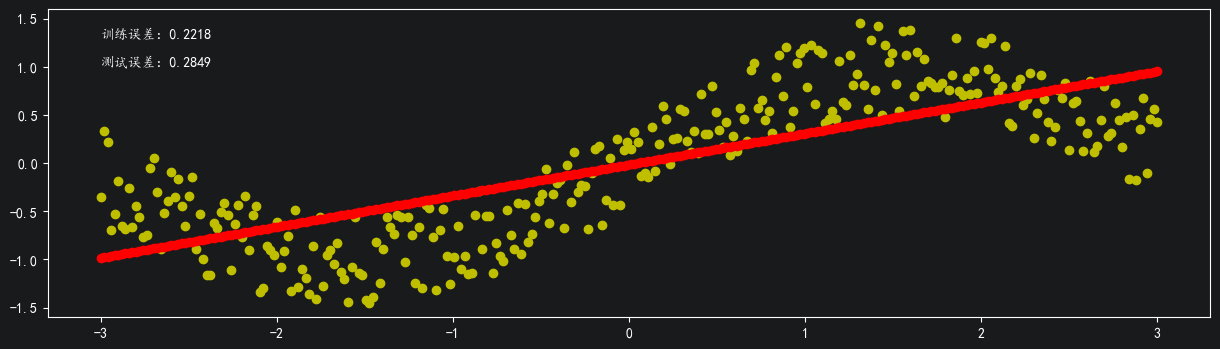

In [18]:
# 画一下图
# 画出散点图
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.scatter(X, y, c='y')
ax.scatter(X, model.predict(X), c='r')
ax.text(-3, 1, f"测试误差：{mse_test:.4f}")
ax.text(-3, 1.3, f"训练误差：{mse_train:.4f}")



(240, 6)


Text(-3, 1.3, '训练误差:0.0744')

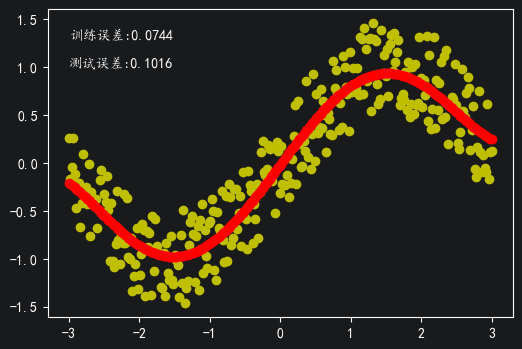

In [26]:
#恰好拟合
# 通过PolynomialFeatures 将X 分解为6个特征。 特征1就是x的5次方，特征2就是x的4次方
poly5 = PolynomialFeatures(degree=5)
X_train_poly2 = poly5.fit_transform(trainX)
X_test_poly2 = poly5.fit_transform(testX)
print(X_train_poly2.shape)
#训练模型
model = LinearRegression()
model.fit(X_train_poly2, trainY)
# 预测结果计算误差
# 计算训练误差
train_mse2 = mean_squared_error(trainY, model.predict(X_train_poly2))
# 计算测试误差
test_mes2 = mean_squared_error(testY, model.predict(X_test_poly2))

# 画图出恰好拟合的那张图
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X, y, c='y')
ax.scatter(X,model.predict(poly5.fit_transform(X)), c='r')
ax.text(-3,1,f"测试误差:{test_mes2:.4f}")
ax.text(-3,1.3,f"训练误差:{train_mse2:.4f}")


(240, 6)


Text(-3, 1.3, '训练误差:0.0682')

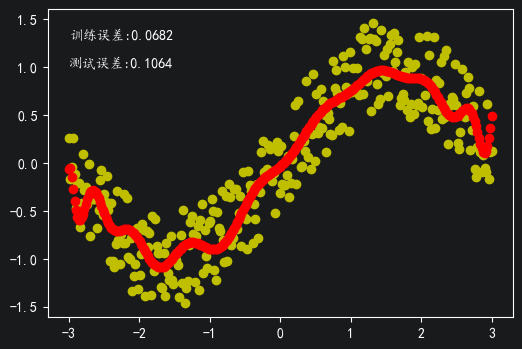

In [38]:
#过拟合的情况
# 通过PolynomialFeatures 将X 分解为20个特征。 特征1就是x的20次方，特征2就是x的19次方
poly20 = PolynomialFeatures(degree=20)
X_train_poly3 = poly20.fit_transform(trainX)
X_test_poly3 = poly20.fit_transform(testX)
print(X_train_poly2.shape)
#训练模型
model = LinearRegression()
model.fit(X_train_poly3, trainY)
# 预测结果计算误差
# 计算训练误差
train_mse3 = mean_squared_error(trainY, model.predict(X_train_poly3))
# 计算测试误差
test_mes3 = mean_squared_error(testY, model.predict(X_test_poly3))

# 画图出恰好拟合的那张图
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X, y, c='y')
ax.scatter(X,model.predict(poly20.fit_transform(X)), c='r')
ax.text(-3,1,f"测试误差:{test_mes3:.4f}")
ax.text(-3,1.3,f"训练误差:{train_mse3:.4f}")